In [1]:
import pandas as pd

train_df = pd.read_csv("../data/train.csv")
val_df = pd.read_csv("../data/val.csv")
test_df = pd.read_csv("../data/test.csv")

In [2]:
train_df.describe()

,serviceCharge,picturecount,pricetrend,yearConstructed,baseRent,livingSpace,noRooms,floor,numberOfFloors,newlyConst,balcony,hasKitchen,cellar,lift,garden,regio2_freq,totalRent
count,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000
mean,139.793800,9.062767,3.296829,1969.945741,558.067104,69.095569,2.553384,1.989545,3.204569,0.078203,0.616579,0.344494,0.639960,0.236395,0.196392,0.011897,701.701676
std,63.154279,4.932243,1.773138,32.748675,295.504944,23.591265,0.844273,1.208368,1.017033,0.268492,0.486221,0.475204,0.480013,0.424868,0.397270,0.014946,310.890174
min,0.000000,0.000000,-1.850000,1881.000000,0.000000,5.000000,1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000045,0.000000
25%,96.000000,6.000000,2.000000,1959.000000,338.000000,54.000000,2.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002031,495.000000
50%,130.000000,9.000000,3.340000,1973.000000,469.450000,66.000000,3.000000,2.000000,3.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.005200,622.000000
75%,179.000000,12.000000,4.480000,1992.000000,710.000000,82.160000,3.000000,3.000000,4.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.013982,825.000000
max,332.280000,23.000000,8.420000,2022.000000,1490.500000,136.500000,4.500000,6.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.051043,1757.530000


In [3]:
train_df = train_df[train_df["totalRent"] > 0]

In [4]:
target = "totalRent"

drop_cols = ["totalRent", "baseRent"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

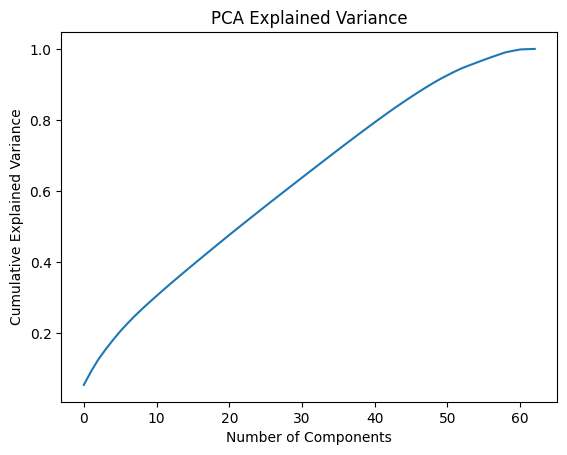

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_scaled)

cumu_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumu_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
model_1 = Pipeline([
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

model_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

model_3 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50)), # 90%
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

model_4 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=55)), # 95%
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

models = {
    "KNN (no scaling)": model_1,
    "KNN + scaling": model_2,
    "KNN + PCA 90%": model_3,
    "KNN + PCA 95% (more components)": model_4
}

# Validation set evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    print(f"{name}: RMSE={rmse:.2f}, R2={r2:.4f}")


KNN (no scaling): RMSE=223.56, R2=0.4801
KNN + scaling: RMSE=221.97, R2=0.4875
KNN + PCA 90%: RMSE=222.87, R2=0.4833
KNN + PCA 95% (more components): RMSE=224.34, R2=0.4765


In [19]:
# Test set evaluation
for name, model in models.items():
    y_test_pred = model.predict(X_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    print(f"{name}: RMSE={rmse_test:.2f}, R2={r2_test:.4f}")

KNN (no scaling): RMSE=225.28, R2=0.4839
KNN + scaling: RMSE=221.50, R2=0.5010
KNN + PCA 90%: RMSE=223.27, R2=0.4930
KNN + PCA 95% (more components): RMSE=223.67, R2=0.4912


In [8]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

from sklearn.metrics import r2_score, root_mean_squared_error

print("RMSE:", root_mean_squared_error(y_val, y_pred))
print("R2:", r2_score(y_val, y_pred))

RMSE: 185.10249642209607
R2: 0.643587717122921


In [9]:
y_test_pred = rf.predict(X_test)
print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Test RMSE: 184.58295638999004
Test R2: 0.653486013679327


In [6]:
drop_cols = ["totalRent"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

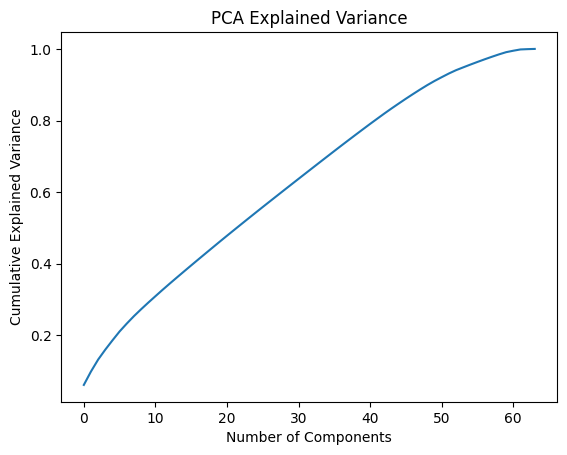

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_scaled)

cumu_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumu_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
model_1 = Pipeline([
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

model_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

model_3 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=55)), # 90%
    ("knn", KNeighborsRegressor(n_neighbors=9))
])


models = {
    "KNN (no scaling)": model_1,
    "KNN + scaling": model_2,
    "KNN + PCA 90%": model_3,
}

# Validation set evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    print(f"{name}: RMSE={rmse:.2f}, R2={r2:.4f}")


KNN (no scaling): RMSE=153.14, R2=0.7560
KNN + scaling: RMSE=191.82, R2=0.6173
KNN + PCA 90%: RMSE=208.11, R2=0.5495


In [9]:
# Test set evaluation
for name, model in models.items():
    y_test_pred = model.predict(X_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    print(f"{name}: RMSE={rmse_test:.2f}, R2={r2_test:.4f}")

KNN (no scaling): RMSE=152.90, R2=0.7622
KNN + scaling: RMSE=192.43, R2=0.6234
KNN + PCA 90%: RMSE=207.68, R2=0.5614


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

from sklearn.metrics import r2_score, root_mean_squared_error

print("RMSE:", root_mean_squared_error(y_val, y_pred))
print("R2:", r2_score(y_val, y_pred))

RMSE: 137.99166318026596
R2: 0.8019231098922663


In [11]:
y_test_pred = rf.predict(X_test)
print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Test RMSE: 137.5212125423096
Test R2: 0.8076567458754977
